In [1]:
import numpy as np 
from pathlib import Path 
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


(-0.5, 9.5, -0.5, 4.5)

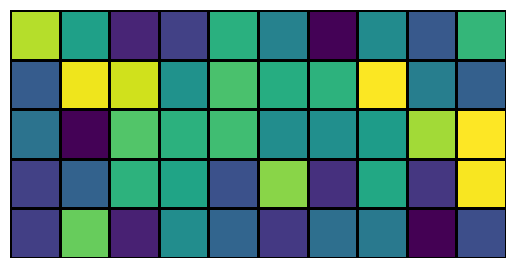

In [2]:
n_rows, n_cols = 5, 10
# y is scaled so that the ratio of the difference between the two dimensions is the same as the ratio of the difference between the two dimensions

x = np.arange(n_cols) # plot columns as width 
y = np.arange(n_rows) # plot rows as height 
# create feature map
feature_map = np.random.rand(n_rows,n_cols,2)


plt.pcolormesh(x, y, feature_map[...,0],  cmap='viridis', edgecolors='k', linewidth=2, snap=True)
plt.gca().set_aspect('equal', adjustable='box')  # Set aspect ratio to 1:1

plt.axis('off')
# plt.set_adjustable("box-forced")


(0.9992779939221711, 0.0027032138935026984)

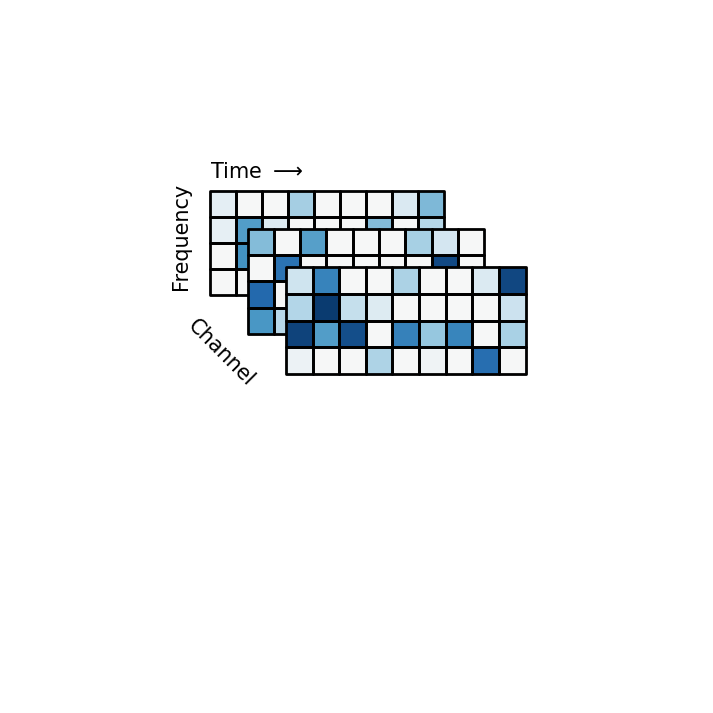

In [178]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)

max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

colors = plt.cm.RdBu(feature_map)
# colors = plt.cm.bwr_r(feature_map)

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)


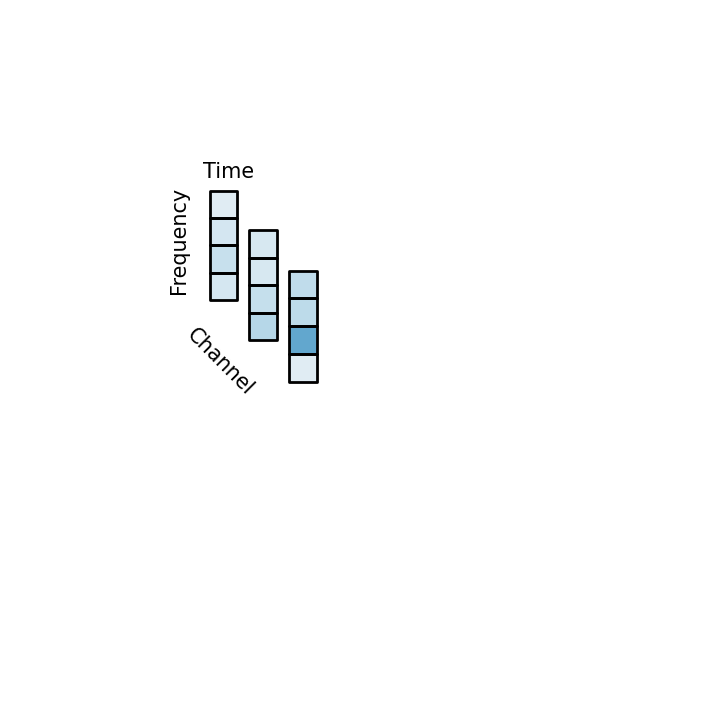

In [152]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
# Create a 3D plot to represent a batch of samples
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot

x = np.arange(0, freq_size)
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

feature_map = np.mean(feature_map, axis=0, keepdims=True)
colors = plt.cm.RdBu(feature_map)
# colors = plt.cm.bwr_r(feature_map)



shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
# scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, -0.25, 0, "Time", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)
ax.set_box_aspect(box_aspect)

# ax.set_xlabel('Frequency')


# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

# plt.show()


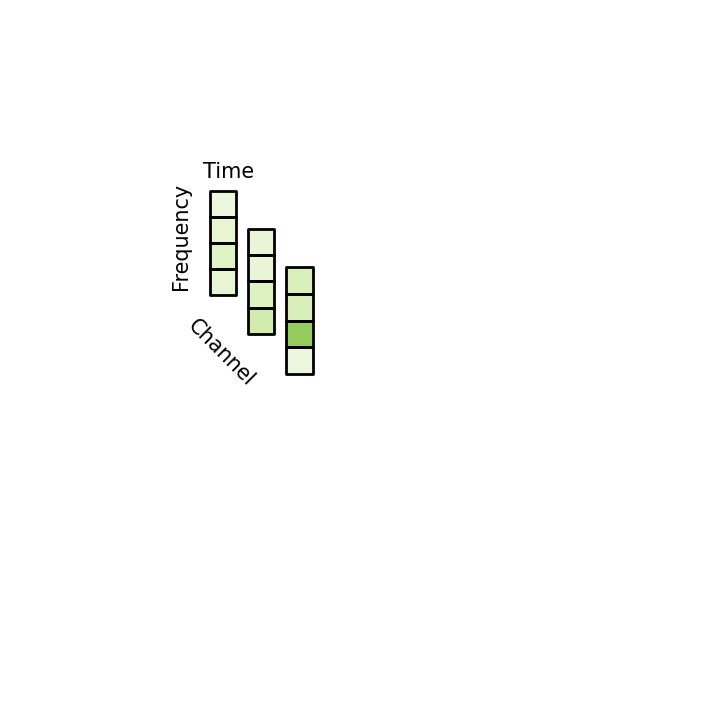

In [115]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
# Create a 3D plot to represent a batch of samples
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot

x = np.arange(0, freq_size)
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

feature_map = np.mean(feature_map, axis=0, keepdims=True)
colors = plt.cm.PiYG(feature_map)
# colors = plt.cm.bwr_r(feature_map)



shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
# scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, -0.25, 0, "Time", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)
ax.set_box_aspect(box_aspect)

# ax.set_xlabel('Frequency')


# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

# plt.show()


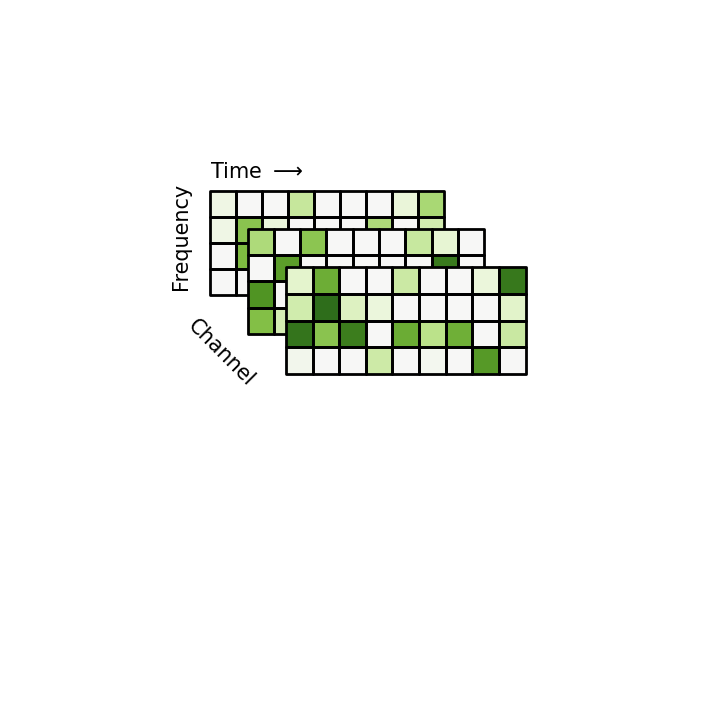

In [174]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)

max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

colors = plt.cm.PiYG(feature_map)
# colors = plt.cm.bwr_r(feature_map)

# max_val = np.max(feature_map)
# pixel_tol = max_val - (max_val * 0.5)

# colors[feature_map < pixel_tol] = 1

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)


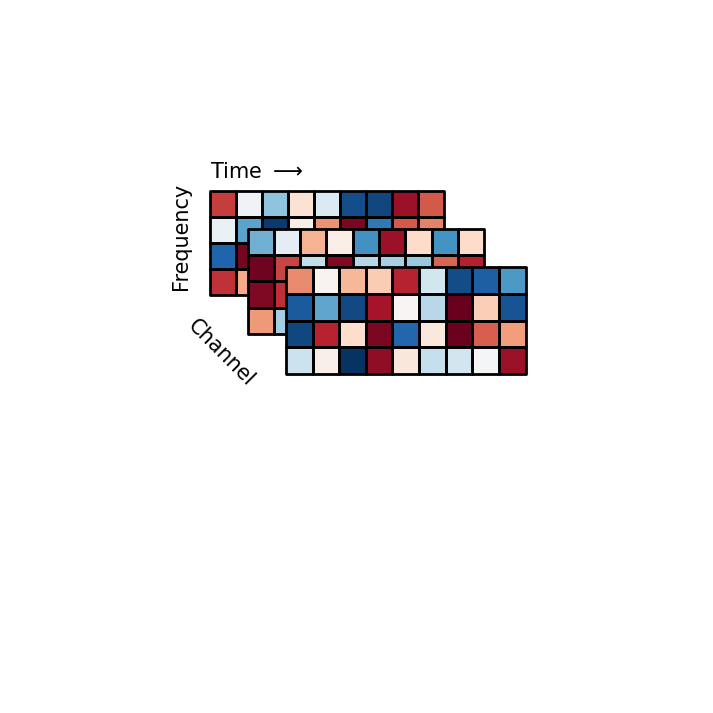

In [171]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(12)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
# feature_map = np.flip(feature_map, axis=1)

colors = plt.cm.RdBu(feature_map)
# colors = plt.cm.bwr_r(feature_map)

# max_val = np.max(feature_map)
# pixel_tol = max_val - (max_val * 0.5)

# colors[feature_map < pixel_tol] = 1

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)


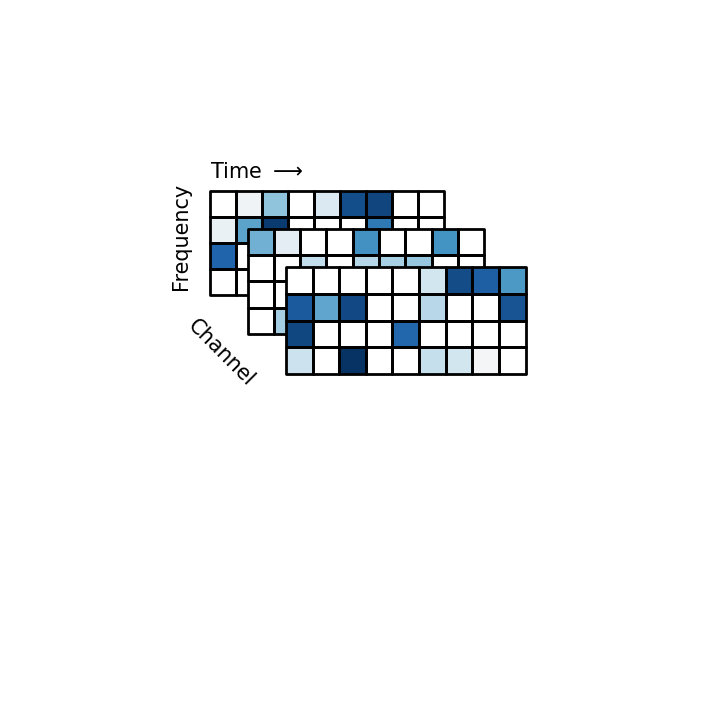

In [141]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(12)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
# feature_map = np.flip(feature_map, axis=1)

colors = plt.cm.RdBu(feature_map)
# colors = plt.cm.bwr_r(feature_map)

max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)

colors[feature_map < pixel_tol] = 1

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)
